In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [5]:
# Let's rename all the files first:

rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)
NList = [4,6,8,10]


for prob in probList:
    for N in NList:
        if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")
            os.rename("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")
        
            
N=4
for rate in rateList:
    if os.path.isfile("RC_raw/S_Z/S2_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out"):
        os.rename("RC_raw/S_Z/S2_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out",
                 "RC_raw/S_Z/S2_S_Z_p=0.0_r=" + str(rate) + "_N=" + str(N) + ".out")
        os.rename("RC_raw/S_Z/purity_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out",
                 "RC_raw/S_Z/purity_S_Z_p=0.0_r=" + str(rate) + "_N=" + str(N) + ".out")
        
    if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out"):
        os.rename("RC_raw/S_Z/S1_S_Z_p=0_r=" + str(rate) + "_N=" + str(N) + ".out",
                 "RC_raw/S_Z/S1_S_Z_p=0.0_r=" + str(rate) + "_N=" + str(N) + ".out")

In [6]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)
NList = [4,6,8,10]

t_total = 400
dt=5
steps = int(t_total/dt)

avgedMI_dynamics_0 = {}
avgedMI_steady_0 = {}

for rate in rateList:
    avgedMI_dynamics_0[rate] = {}
    avgedMI_steady_0[rate] = {}

    for prob in probList: 
        avgedMI_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedMI_dynamics_0[rate][prob] = np.average(temp,axis=0)
                
                steps = temp.shape[1]//5

                avgedMI_steady_0[rate][prob][n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])
            
            else:
                #print("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out")
                print('missing rate=',rate,',prob=', prob,'N=',N)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 1000.0 ,prob= 0.2 N= 10


Text(0.5, 1.0, 'dephasing rate = 1000.0')

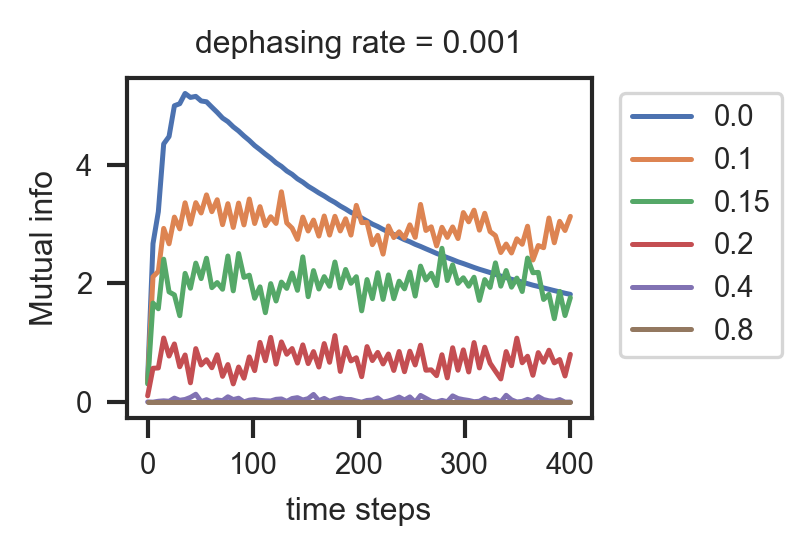

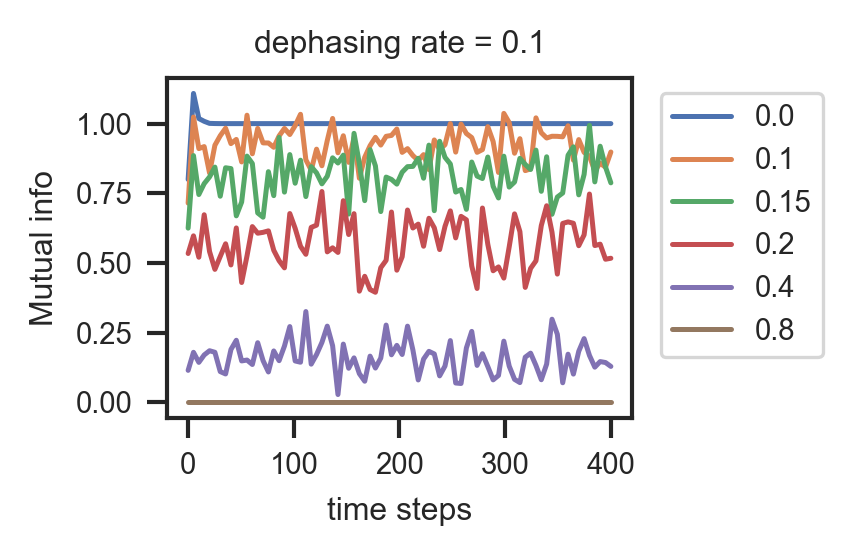

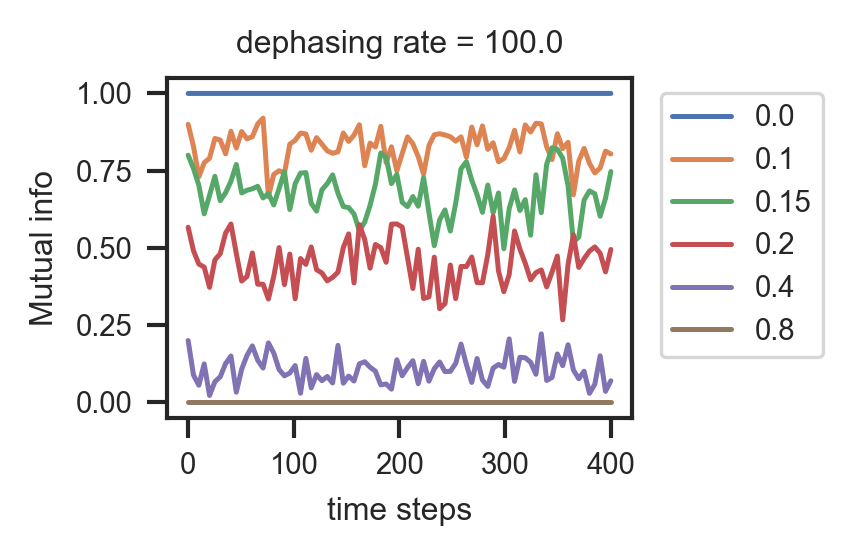

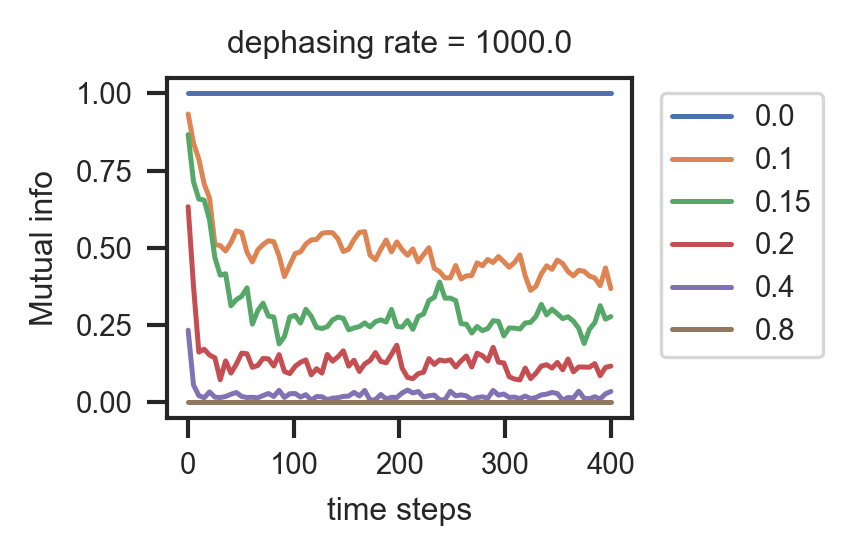

In [7]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.1,0.15,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dephasing rate = ' + str(rate))

plt.figure()
rate = 0.1
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dephasing rate = ' + str(rate))



plt.figure()
rate = 100.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dephasing rate = ' + str(rate))


plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('Mutual info')
plt.title('dephasing rate = ' + str(rate))




[5.34865085 1.98953653 1.         1.         1.         1.
 1.         0.99999999]
[3.59709651 2.76429805 1.41283114 0.91558977 0.91658386 0.90440184
 0.81212223 0.41326802]
[2.11675223 1.94864015 1.21268969 0.82760165 0.76467565 0.81141847
 0.67964086 0.26995487]
[1.37176828 1.19649826 0.91755515 0.7089278  0.69775272 0.66762119
 0.56729196 0.18897725]
[0.73448112 0.68988385 0.64144153 0.58749639 0.63520713 0.61104119
 0.44148806 0.11108541]
[0.21494281 0.21460242 0.2502036  0.34883869 0.42692464 0.37662371
 0.27557198 0.07557851]
[0.06187339 0.03555802 0.0639407  0.15853664 0.19776739 0.1960527
 0.10493615 0.02042895]
[-5.50191839e-14 -9.13510458e-15 -2.66284828e-16 -4.92860515e-15
 -3.75668496e-15  5.13382466e-15  4.51332762e-14 -2.06887962e-17]


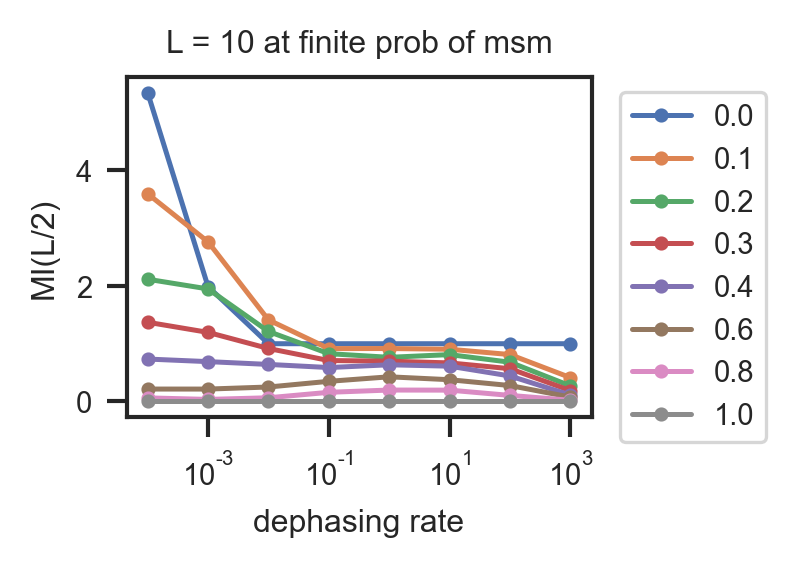

In [11]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, .8, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]

plt.figure()
for prob in probTempList:
    MIinRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        MIinRate[r] = avgedMI_steady_0[rate][prob][2]
    print(MIinRate)
    plt.semilogx(np.array(rateTempList).astype(float), MIinRate,'.-')
    plt.xlabel('dephasing rate')
    plt.ylabel('MI(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



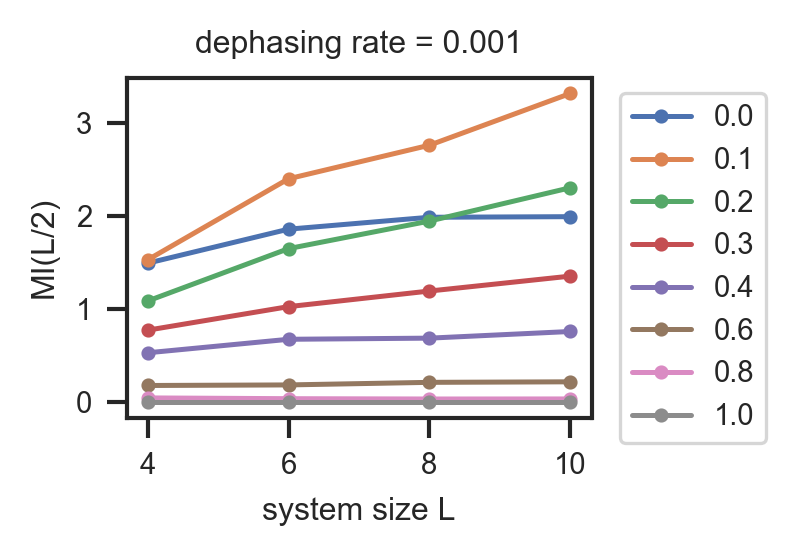

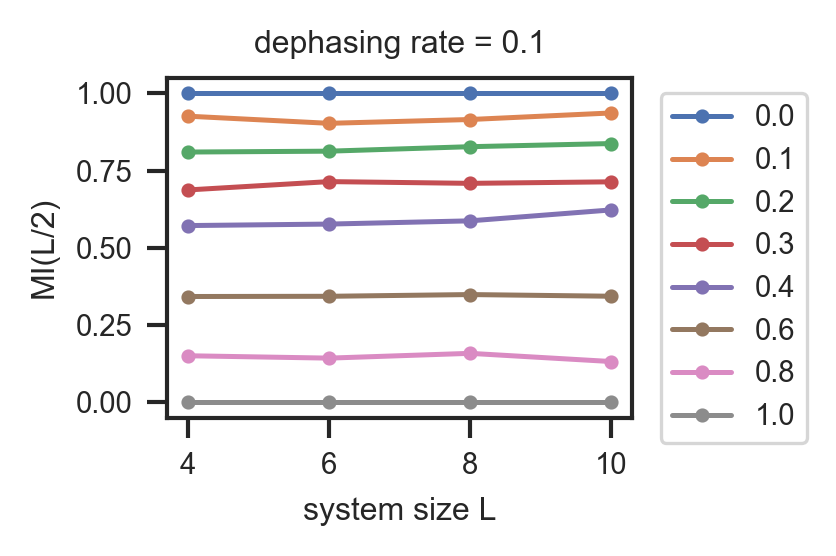

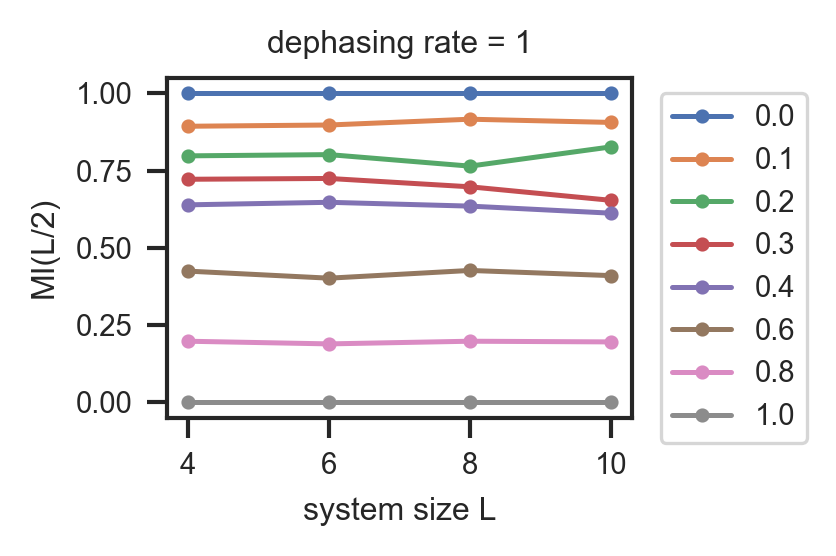

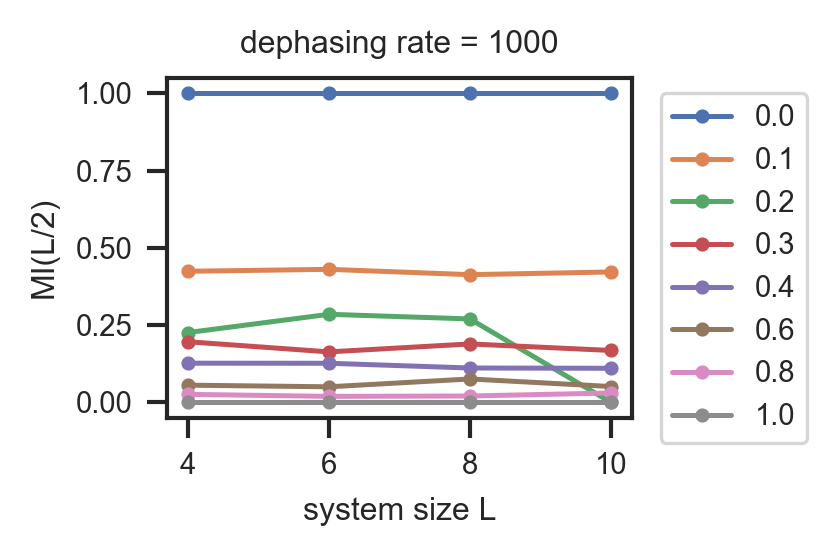

In [9]:
rateTempList = [0.001,0.1,1,1000]

for rate in rateTempList:
    plt.figure()
    for prob in probTempList:
        plt.plot(np.array(NList), avgedMI_steady_0[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('MI(L/2)')
        plt.title('dephasing rate = ' + str(rate))
    plt.legend(probTempList,bbox_to_anchor= (1.03, 1))


NameError: name 'avgedS1_steady_0' is not defined

<Figure size 600x450 with 0 Axes>

In [125]:
avgedS_dynamics_0 = {}
avgedS_steady_0 = {}

for rate in rateList:
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedS_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedS_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedS_steady_0[rate][prob][n] = np.average(temp[steps:])
        #else:
            #print('missing rate=',rate,', prob=', prob)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



Text(0.5, 1.0, 'dephasing rate = 1000.0')

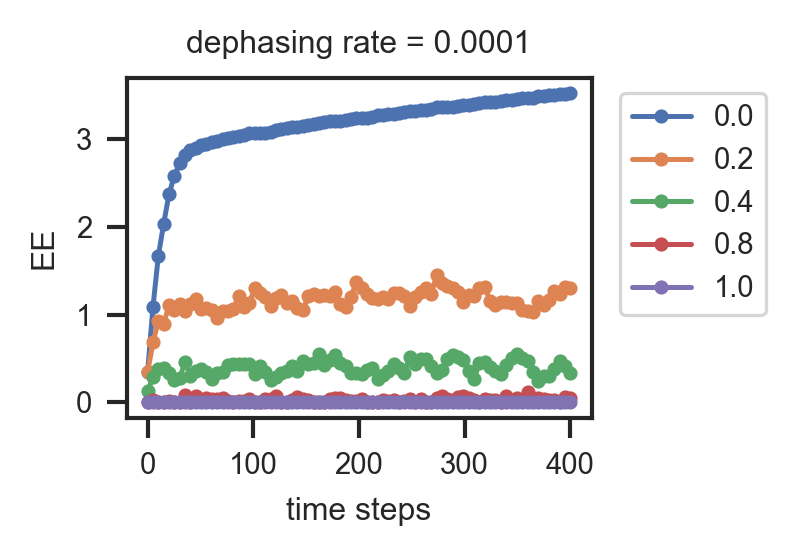

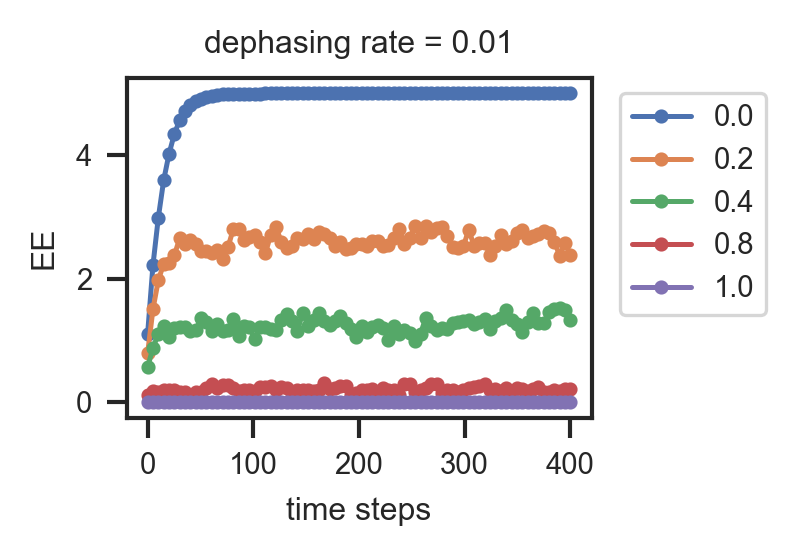

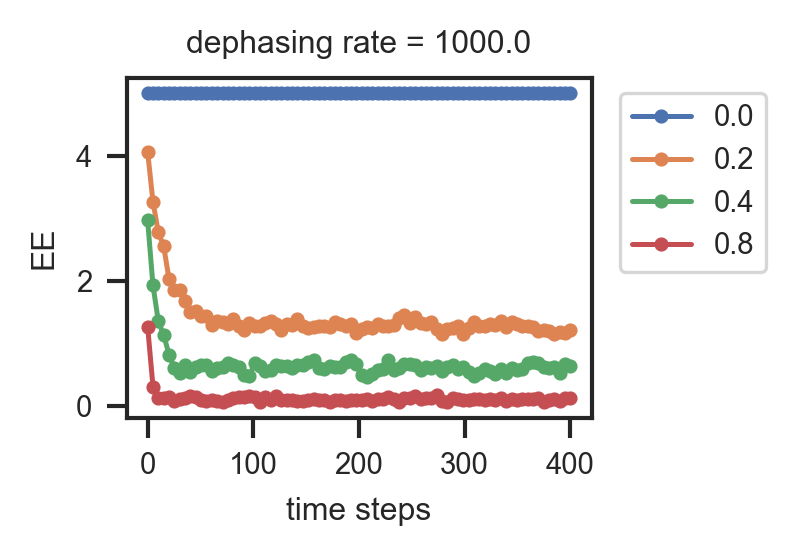

In [178]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.0001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('EE')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 0.01
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('EE')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 
    N=8
    if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.xlabel('time steps')
plt.ylabel('EE')
plt.title('dephasing rate = ' + str(rate))



In [127]:
avgedStot_dynamics_0 = {}
avgedStot_steady_0 = {}

for rate in rateList:
    avgedStot_dynamics_0[rate] = {}
    avgedStot_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedStot_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedStot_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedStot_steady_0[rate][prob][n] = np.average(temp[steps:])
        #else:
            #print('missing rate=',rate,', prob=', prob)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



Text(0, 0.5, 'Total Entropy')

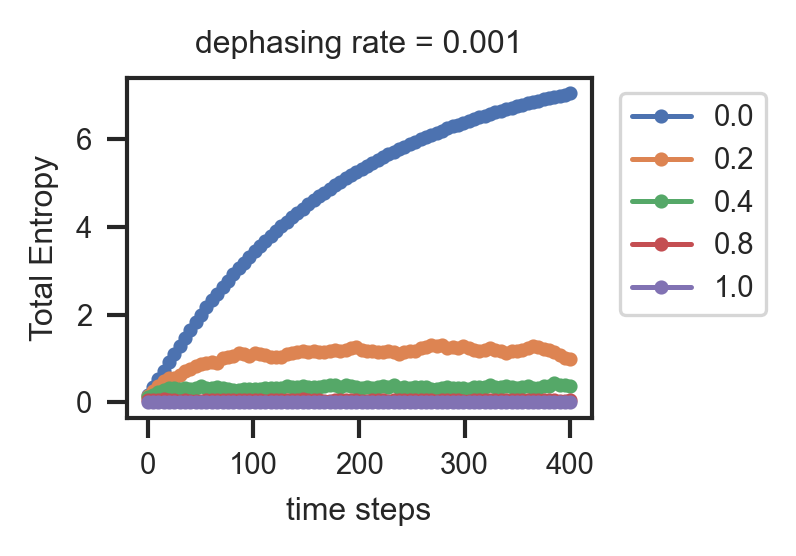

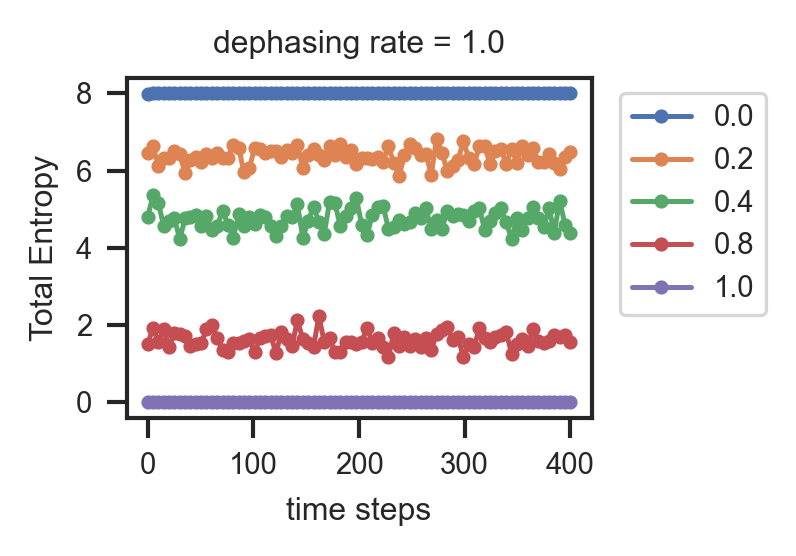

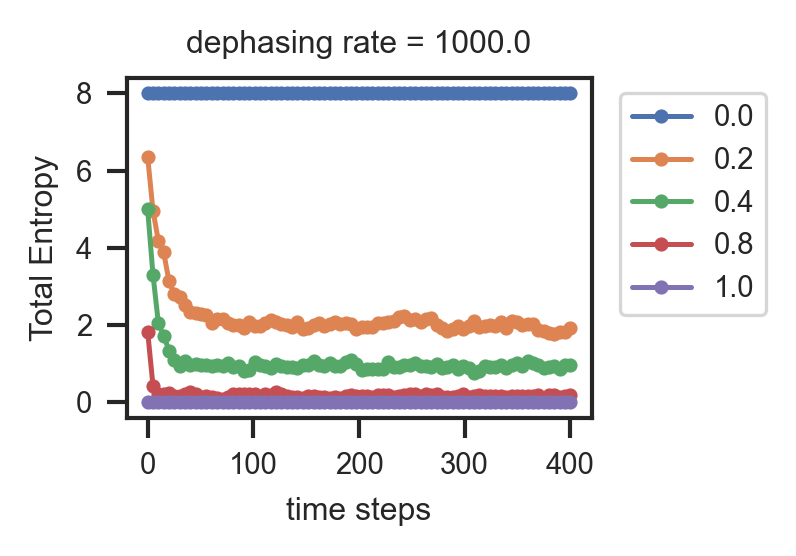

In [128]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Total Entropy')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Total Entropy')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Total Entropy')



In [129]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)
NList = [4,6,8,10]

t_total = 400
dt=5
steps = int(t_total/dt)

avgedP_dynamics_0 = {}
avgedP_steady_0 = {}

for rate in rateList:
    avgedP_dynamics_0[rate] = {}
    avgedP_steady_0[rate] = {}

    for prob in probList: 
        avgedP_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedP_dynamics_0[rate][prob] = np.average(temp,axis=0)
                
                steps = len(temp)//2

                avgedP_steady_0[rate][prob][n] = np.average(temp[steps:])
            
            #"S1_S_minus_p=0.75_r=0.01_N=10.out"
            else:
                print('missing rate=',rate,',prob=', prob,'N=',N)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 1000.0 ,prob= 0.2 N= 10


Text(0, 0.5, 'Purity')

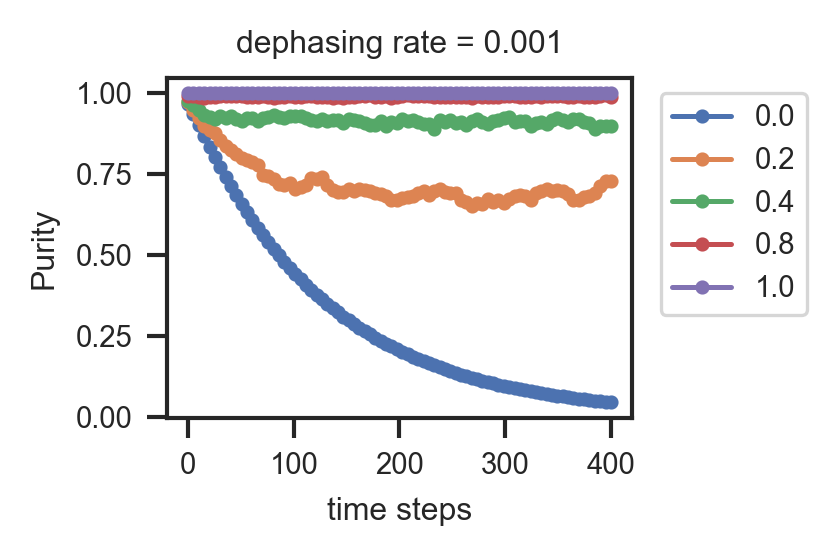

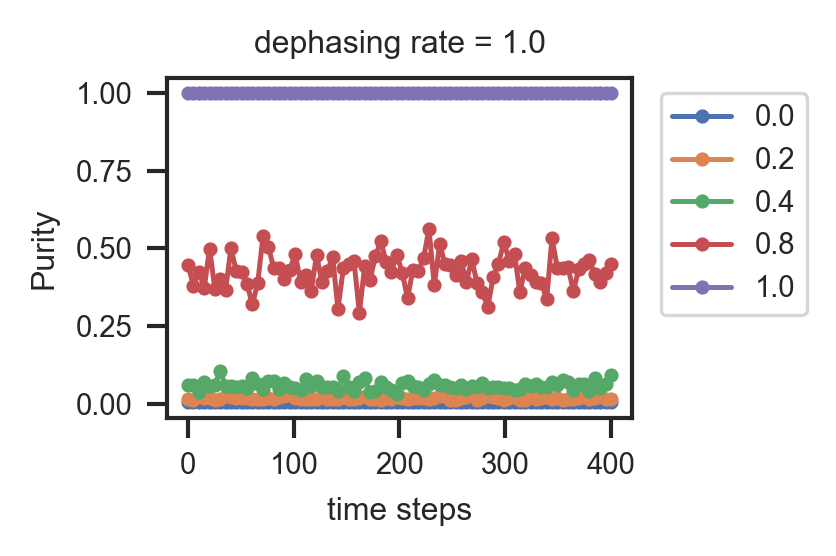

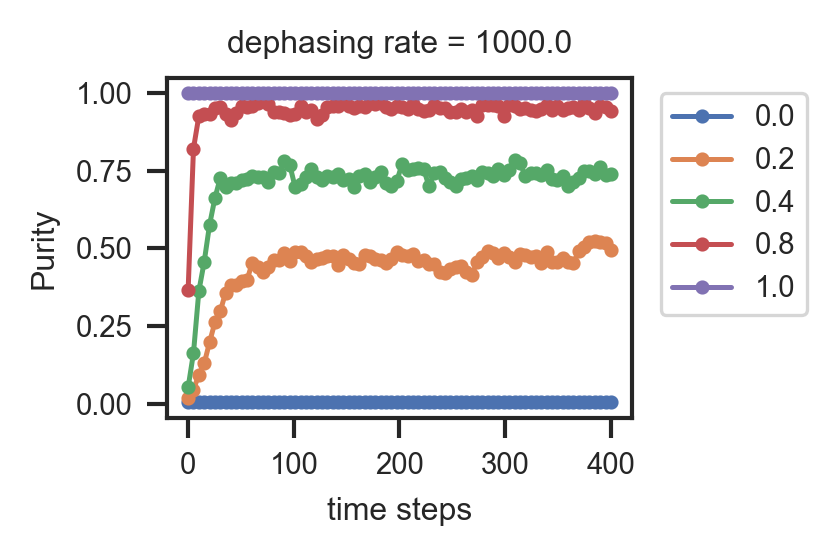

In [130]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 400
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

probTempList = [0.0,0.2, 0.4,0.8, 1.0]
plt.figure()
rate = 0.001
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Purity')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Purity')

probTempList = [0.0,0.2, 0.4, 0.8, 1.0]
plt.figure()
rate = 1000.0
for prob in probTempList: 

    N=8
    if os.path.isfile("RC_raw/S_Z/Stot_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.average(temp,axis=0),'.-')

plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )
plt.title('dephasing rate = ' + str(rate))
plt.xlabel('time steps')
plt.ylabel('Purity')



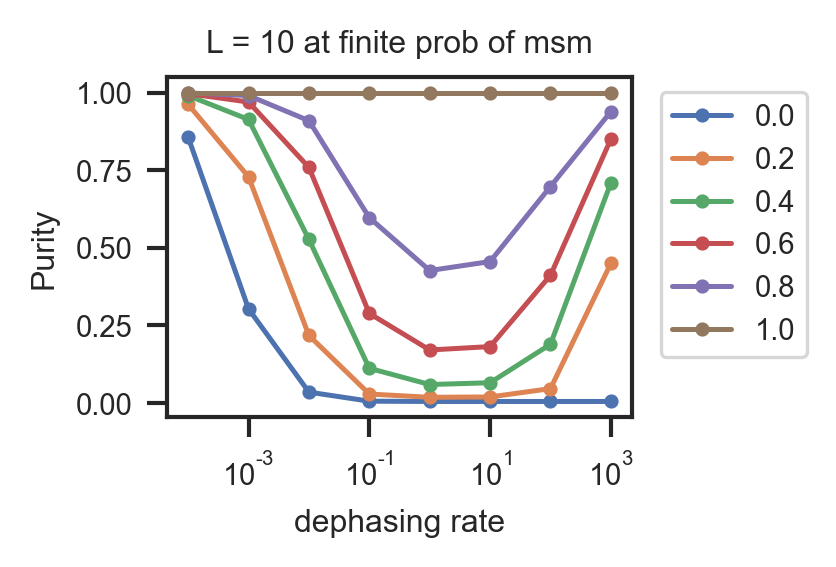

In [131]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.2, 0.4, 0.6, .8, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]

plt.figure()
for prob in probTempList:
    PinRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        PinRate[r] = avgedP_steady_0[rate][prob][2]
    plt.semilogx(np.array(rateTempList).astype(float), PinRate,'.-')
    plt.xlabel('dephasing rate')
    plt.ylabel('Purity')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



In [175]:
avgedS1_dynamics_0 = {}
avgedS1_steady_0 = {}

rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)

for rate in rateList:
    avgedS1_dynamics_0[rate] = {}
    avgedS1_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/S_Z/S1_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedS1_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedS1_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedS1_steady_0[rate][prob][n] = np.average(temp[-10:])
                
        else:
            print('missing rate=',rate,',prob=', prob,'N=',N)



missing rate= 1000.0 ,prob= 0.2 N= 10


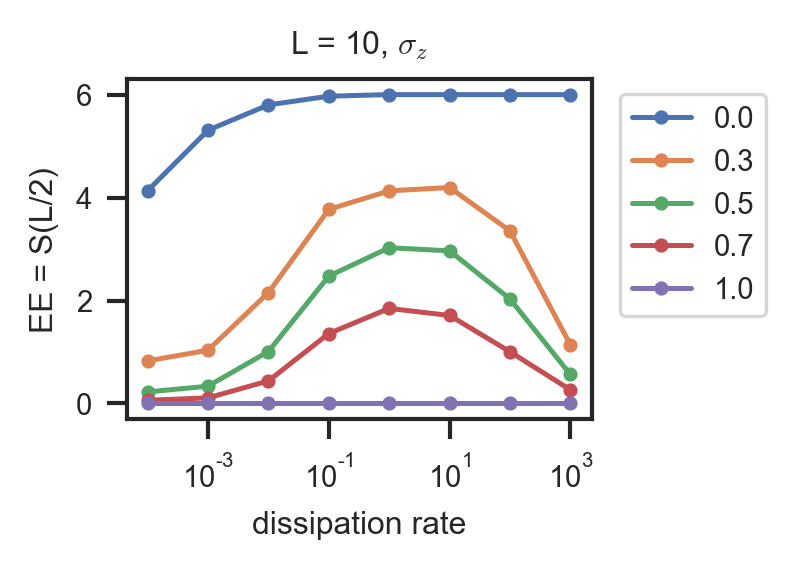

In [177]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.0, 0.3, 0.5, .7, 1.0]
rateTempList = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0,1000.0]


plt.figure()
for prob in probTempList:
    S1InRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        S1InRate[r] = avgedS1_steady_0[rate][prob][3]
    plt.semilogx(np.array(rateTempList).astype(float), S1InRate,'.-')
    plt.xlabel('dissipation rate')
    plt.ylabel('EE = S(L/2)')
plt.title('L = 10, $\sigma_z$')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



0.6724667484458295
0.019876534298326167
0.000976562500001309
0.0009765624999999137
0.0009765624999998716
0.0009765624999999137
0.0009765624999998716
0.0009765625000000481
0.000976562584305811
Safe to say that they plateau to the same value due to finite size effect.


Text(0, 0.5, 'purity')

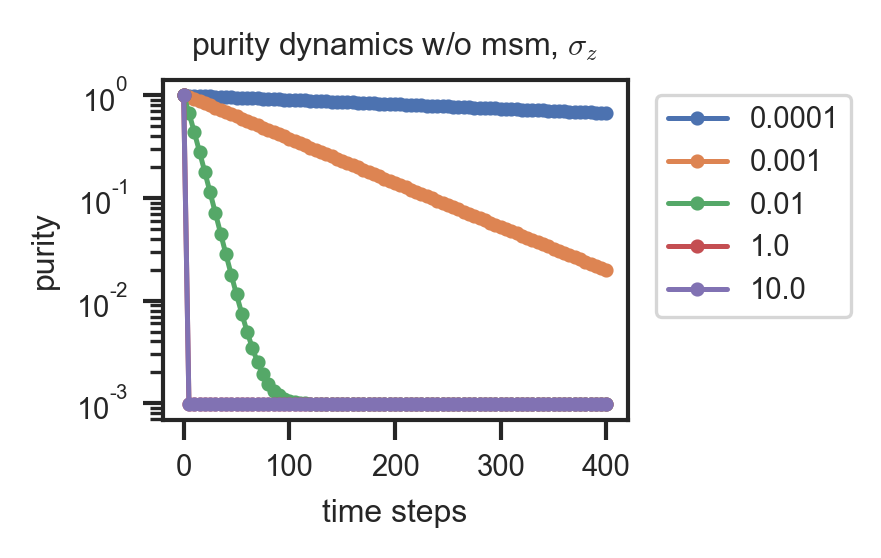

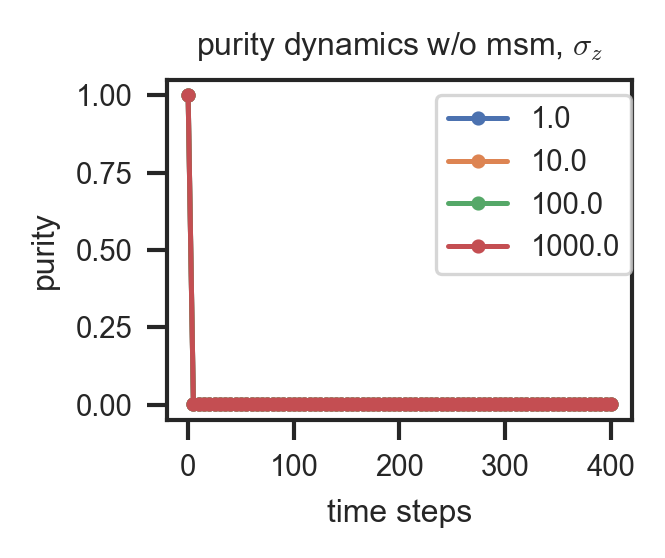

In [157]:
prob=0.0
rateList = [1e-4,1e-3,1e-2,1e0,1e1]
duration = np.linspace(0,t_total,int(t_total/dt)+1)

for rate in rateList: 
    N=10
    if os.path.isfile("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.semilogy(duration, np.concatenate([np.array([1]), np.average(temp,axis=0)]),'.-')
        print(np.average(temp,axis=0)[-1])

plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.title('purity dynamics w/o msm, $\sigma_z$')
plt.xlabel('time steps')
plt.ylabel('purity')

rateList = np.logspace(0,3,4)
plt.figure()
for rate in rateList: 
    N=10
    if os.path.isfile("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
        temp = np.array(np.loadtxt("RC_raw/S_Z/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
        #print(np.average(temp,axis=0).shape)
        plt.plot(duration, np.concatenate([ np.array([1]), np.average(temp,axis=0)]),'.-')
        print(np.average(temp,axis=0)[-1])
print("Safe to say that they plateau to the same value due to finite size effect.")

plt.legend(rateList,bbox_to_anchor= (1.03, 1) )
plt.title('purity dynamics w/o msm, $\sigma_z$')
plt.xlabel('time steps')
plt.ylabel('purity')
